In [1]:
pip install sentence-transformers scikit-learn seaborn matplotlib pandas

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
model=SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
if model:
  print("Model sucessfully loaded")
else:
  print("Error")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model sucessfully loaded


In [7]:
anchors = {
    "Vitalidade (Ação)": "Cores vibrantes, alto contraste, assimetria, movimento capturado, luz do sol intensa, energia caótica e alegre,vibração diurna, ação atlética.",
    "Solenidade (Estase)": "Simetria rígida, fundo limpo e minimalista, iluminação suave e equilibrada, cores neutras, estático e pacífico.",
    "Conexão (Close-up)": "Sorriso aberto, retrato bem próximo, foco extremo nos olhos, pele nítida, amigável, calor humano, proximidade.",
    "Distanciamento (Low-key)": "Silhueta escura, espaço vazio gigante, sombras dominantes, pessoa encolhida ou de costas, frio, solidão visual.",
    "Simplicidade (Cotidiano)": "Iluminação natural de janela, saturação média, baixo contraste, ambiente doméstico ordinário, textura comum.",
    "Conflito (Caos)": "Sujeira urbana, texturas ásperas e arranhadas, multidão desordenada, cena de rua confusa, poluição visual extrema.",
    "Nostalgia (Analógico)": "Cores desbotadas, tom pastel, ruído e granulação, luz quente de fim de tarde, estética analógica e envelhecida.",
    "Sublime (Paisagem)": "Escala grandiosa, sujeito minúsculo perante uma paisagem massiva, saturação intensa, exposição perfeita, tirar o fôlego.",
    "Corporativo (Focado)": "Retrato profissional, pessoa focada, fundo liso ou levemente desfocado, iluminação de estúdio neutra e limpa.",
    "Noturno (Festa)": "Escuridão da madrugada, luzes de neon brilhantes, flash de câmera estourado, balada, vida noturna artificial."
}
name_anchors = list(anchors.keys())
text_anchors = list(anchors.values())

In [8]:
embeddings = model.encode(text_anchors)
vector_similarity = cosine_similarity(embeddings)
np.fill_diagonal(vector_similarity, 0)


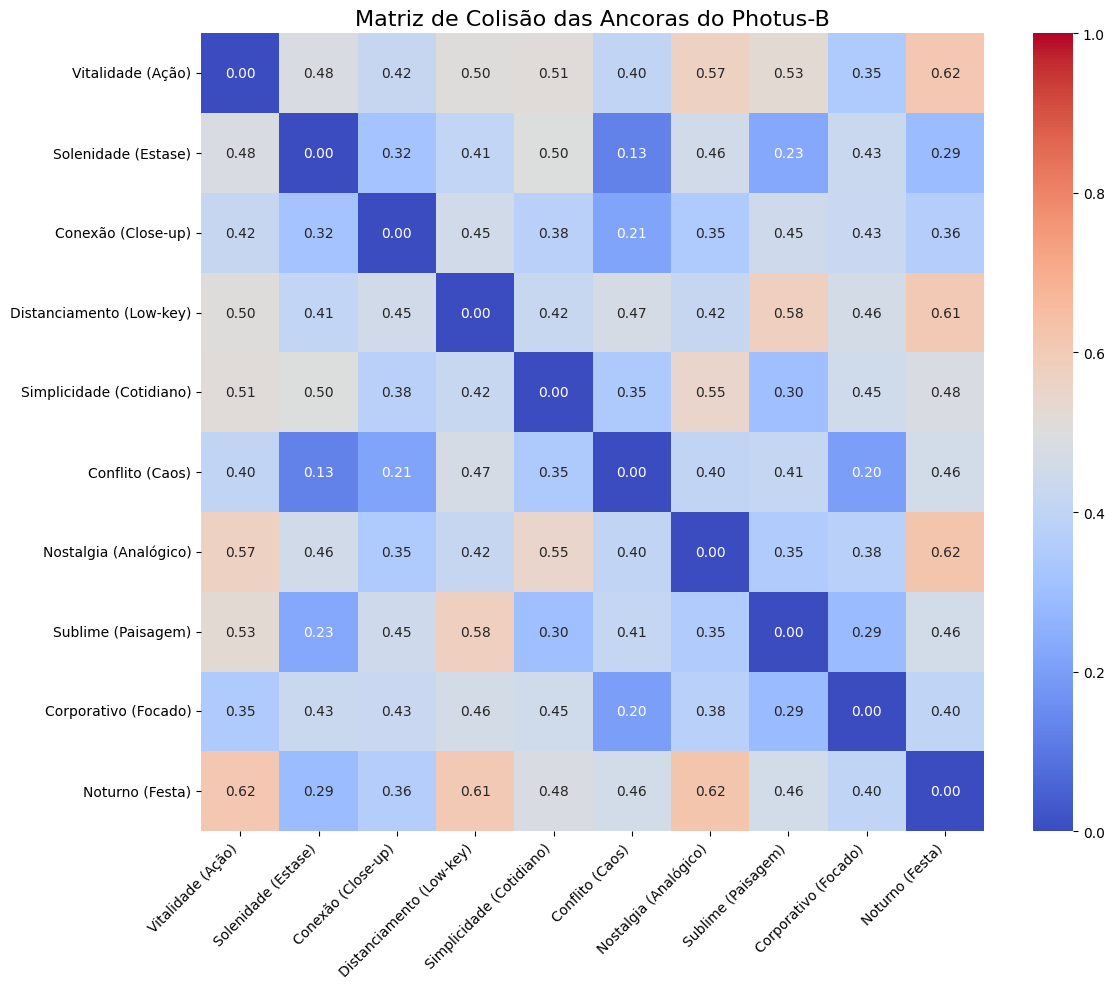

In [9]:
plt.figure(figsize=(12,10))
df_sim = pd.DataFrame(vector_similarity, index=name_anchors, columns=name_anchors)
sns.heatmap(df_sim,annot=True,cmap="coolwarm",fmt=".2f",vmin=0,vmax=1)
plt.title("Matriz de Colisão das Ancoras do Photus-B",fontsize=16)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()